# Production Optimization with Topside Facility Coupling

This notebook demonstrates **integrated production optimization** from subsurface reservoirs,
through a subsea gathering network, to a topside processing facility using NeqSim.

## Scenario: Offshore Gas-Condensate Platform

- **4 wells** producing from **2 reservoirs** (different pressures, compositions)
- **Subsea gathering network** with IPR models, chokes, and flowlines
- **Topside facility** with inlet separator, scrubber, and export compressor
- **Objective**: Maximize revenue while respecting topside equipment capacity

### What This Notebook Covers

1. **Subsurface + Network Model** — Multi-reservoir, multi-well gathering system
2. **Topside Process Model** — Separator, scrubber, compressor with capacity constraints
3. **Coupled Optimization** — Iterative network ↔ topside loop with back-pressure feedback
4. **Capacity Utilization Dashboard** — Separator loading, compressor power, bottleneck identification
5. **Production Scenarios** — Late-life decline with topside re-optimization
6. **Improvement Proposals** — Gaps and recommendations for future development

### Architecture

```
Reservoir A (280 bara)        Reservoir B (220 bara)
  ├─ Well A1 (PI=5e-6)          ├─ Well B1 (PI=4e-6)
  └─ Well A2 (PI=4.5e-6)        └─ Well B2 (PI=3e-6)
       │                              │
     Chokes                         Chokes
       │                              │
       └──── Subsea Manifold ─────────┘
                    │
              Export Flowline (25 km)
                    │
         ┌──── Platform Arrival ────┐
         │   Inlet Separator        │
         │   ├─ Gas → Scrubber      │
         │   │    └─ Compressor     │
         │   │         └─ Export    │
         │   └─ Liquid → Storage    │
         └──────────────────────────┘
```

In [1]:
# =============================================================================
# Cell 1: Setup — NeqSim + Imports
# =============================================================================
import importlib, subprocess, sys, os

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

import jpype
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

# Import NeqSim Java classes
LoopedPipeNetwork = jpype.JClass("neqsim.process.equipment.network.LoopedPipeNetwork")
SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
Separator = jpype.JClass("neqsim.process.equipment.separator.Separator")
Compressor = jpype.JClass("neqsim.process.equipment.compressor.Compressor")
Cooler = jpype.JClass("neqsim.process.equipment.heatexchanger.Cooler")
ThrottlingValve = jpype.JClass("neqsim.process.equipment.valve.ThrottlingValve")
ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print(f"Mode: {NEQSIM_MODE}")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)
Mode: devtools


## Part 1: Define Reservoir Fluids and Subsea Network

We model two reservoirs with slightly different compositions:
- **Reservoir A**: Lean gas (higher methane, 280 bara)
- **Reservoir B**: Richer gas-condensate (more C3+, 220 bara)

In [2]:
# =============================================================================
# Cell 2: Create reservoir fluids
# =============================================================================

# Reservoir A — lean gas
fluid_A = SystemSrkEos(273.15 + 90.0, 280.0)
fluid_A.addComponent("methane", 0.88)
fluid_A.addComponent("ethane", 0.06)
fluid_A.addComponent("propane", 0.03)
fluid_A.addComponent("n-butane", 0.01)
fluid_A.addComponent("CO2", 0.015)
fluid_A.addComponent("nitrogen", 0.005)
fluid_A.setMixingRule("classic")

# Reservoir B — richer gas-condensate
fluid_B = SystemSrkEos(273.15 + 95.0, 220.0)
fluid_B.addComponent("methane", 0.78)
fluid_B.addComponent("ethane", 0.09)
fluid_B.addComponent("propane", 0.06)
fluid_B.addComponent("n-butane", 0.03)
fluid_B.addComponent("n-pentane", 0.01)
fluid_B.addComponent("CO2", 0.02)
fluid_B.addComponent("nitrogen", 0.01)
fluid_B.setMixingRule("classic")

# Network fluid template (combined — used for pipe flow calcs)
gas = SystemSrkEos(273.15 + 15.0, 50.0)
gas.addComponent("methane", 0.85)
gas.addComponent("ethane", 0.07)
gas.addComponent("propane", 0.04)
gas.addComponent("n-butane", 0.02)
gas.addComponent("CO2", 0.015)
gas.addComponent("nitrogen", 0.005)
gas.setMixingRule("classic")

print(f"Reservoir A: {fluid_A.getNumberOfComponents()} components, pRes=280 bara")
print(f"Reservoir B: {fluid_B.getNumberOfComponents()} components, pRes=220 bara")
print(f"Network template: {gas.getNumberOfComponents()} components")

Reservoir A: 6 components, pRes=280 bara
Reservoir B: 7 components, pRes=220 bara
Network template: 6 components


In [3]:
# =============================================================================
# Cell 3: Build subsea gathering network
# =============================================================================

net = LoopedPipeNetwork("Offshore Production")
net.setFluidTemplate(gas)
net.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net.setMaxIterations(200)
net.setTolerance(float(100.0))

# --- Reservoir A: 2 wells (lean gas, high pressure) ---
net.addSourceNode("resA", float(280.0), float(0.0))
net.addJunctionNode("bhp_A1")
net.addJunctionNode("bhp_A2")
net.addJunctionNode("wh_A1")
net.addJunctionNode("wh_A2")

# Well IPRs from Reservoir A (shared source node)
net.addWellIPR("resA",  "bhp_A1", "ipr_A1", float(5e-6), False)
net.addWellIPR("resA",  "bhp_A2", "ipr_A2", float(4.5e-6), False)
# Chokes
net.addChoke("bhp_A1", "wh_A1", "choke_A1", float(40.0), float(70.0))
net.addChoke("bhp_A2", "wh_A2", "choke_A2", float(40.0), float(60.0))

# --- Reservoir B: 2 wells (rich gas, lower pressure) ---
net.addSourceNode("resB", float(220.0), float(0.0))
net.addJunctionNode("bhp_B1")
net.addJunctionNode("bhp_B2")
net.addJunctionNode("wh_B1")
net.addJunctionNode("wh_B2")

net.addWellIPR("resB",  "bhp_B1", "ipr_B1", float(4e-6), False)
net.addWellIPR("resB",  "bhp_B2", "ipr_B2", float(3e-6), False)
net.addChoke("bhp_B1", "wh_B1", "choke_B1", float(35.0), float(65.0))
net.addChoke("bhp_B2", "wh_B2", "choke_B2", float(35.0), float(55.0))

# --- Subsea manifold (junction of all wells) ---
net.addJunctionNode("manifold")
net.addPipe("wh_A1", "manifold", "fl_A1", float(5000.0), float(0.20), float(0.00005))
net.addPipe("wh_A2", "manifold", "fl_A2", float(4000.0), float(0.20), float(0.00005))
net.addPipe("wh_B1", "manifold", "fl_B1", float(6000.0), float(0.20), float(0.00005))
net.addPipe("wh_B2", "manifold", "fl_B2", float(7000.0), float(0.20), float(0.00005))

# --- Export flowline to platform ---
net.addFixedPressureSinkNode("platform", float(65.0))  # Initial topside arrival P
net.addPipe("manifold", "platform", "export_fl", float(25000.0), float(0.30), float(0.00005))

# Set per-well compositions
net.setNodeFluid("resA", fluid_A)
net.setNodeFluid("resB", fluid_B)

# Oil/gas pricing (lean gas wells get gas price, rich wells get premium)
net.setWellPrice("choke_A1", float(0.30))   # USD/kg
net.setWellPrice("choke_A2", float(0.30))
net.setWellPrice("choke_B1", float(0.45))   # Premium for condensate-rich gas
net.setWellPrice("choke_B2", float(0.45))

# Solve the network
net.run()

# Print well-by-well results
print("=" * 75)
print("Subsea Network — Baseline (Before Optimization)")
print("=" * 75)
wells = [("A1", "ipr_A1", "choke_A1", "wh_A1", "resA"),
         ("A2", "ipr_A2", "choke_A2", "wh_A2", "resA"),
         ("B1", "ipr_B1", "choke_B1", "wh_B1", "resB"),
         ("B2", "ipr_B2", "choke_B2", "wh_B2", "resB")]

print(f"\n{'Well':<8} {'Reservoir':<12} {'pRes':>8} {'BHP':>8} {'WHP':>8} {'Rate (kg/hr)':>14} {'Choke %':>8}")
print("-" * 70)
total_flow = 0.0
for wname, ipr, chk, wh, res in wells:
    rate = abs(float(net.getPipeFlowRate(ipr)))
    bhp = float(net.getNodePressure(ipr.replace('ipr_', 'bhp_')))
    whp = float(net.getNodePressure(wh))
    pres = float(net.getNodePressure(res))
    choke_pipe = net.getPipe(chk)
    opening = float(choke_pipe.getChokeOpening())
    total_flow += rate
    print(f"{wname:<8} {res:<12} {pres:>8.1f} {bhp:>8.1f} {whp:>8.1f} {rate:>14.0f} {opening:>8.1f}")
print("-" * 70)
manifold_p = float(net.getNodePressure("manifold"))
platform_p = float(net.getNodePressure("platform"))
print(f"Total production: {total_flow:.0f} kg/hr")
print(f"Manifold pressure: {manifold_p:.1f} bara")
print(f"Platform arrival: {platform_p:.1f} bara")

Subsea Network — Baseline (Before Optimization)

Well     Reservoir        pRes      BHP      WHP   Rate (kg/hr)  Choke %
----------------------------------------------------------------------
A1       resA            280.0    242.9    121.5          66700     70.0
A2       resA            280.0    238.2    119.1          67645     60.0
B1       resB            220.0    212.4    108.7          11013     65.0
B2       resB            220.0    211.4    108.6           9280     55.0
----------------------------------------------------------------------
Total production: 154638 kg/hr
Manifold pressure: 108.2 bara
Platform arrival: 65.0 bara


## Part 2: Topside Process Facility

Build a simplified topside process train:
1. **Inlet separator** (horizontal, 3.0 m ID × 12 m) — separates gas from condensate
2. **Gas scrubber** — polishes gas before compression
3. **Export compressor** — compresses to export pipeline pressure (150 bara)
4. **Export cooler** — cools compressed gas

We size the equipment with design capacities and check utilization.

In [6]:
# =============================================================================
# Cell 4: Build topside process model
# =============================================================================

def build_topside(feed_stream):
    """Build a topside processing train from the network outlet stream."""
    process = ProcessSystem()

    # Feed stream from network
    feed = Stream("Topside Feed", feed_stream.getFluid().clone())
    feed.setFlowRate(feed_stream.getFlowRate("kg/hr"), "kg/hr")
    feed.setPressure(feed_stream.getPressure("bara"), "bara")
    feed.setTemperature(feed_stream.getTemperature("C"), "C")
    process.add(feed)

    # Inlet separator — sized for design capacity
    inlet_sep = Separator("Inlet Separator", feed)
    inlet_sep.setInternalDiameter(2.4)          # 2.4 m ID
    inlet_sep.setSeparatorLength(10.0)           # 10 m long
    inlet_sep.setOrientation("horizontal")
    inlet_sep.setDesignGasLoadFactor(0.06)       # K-factor (Souders-Brown)
    process.add(inlet_sep)

    # Export compressor on gas outlet
    gas_out = inlet_sep.getGasOutStream()
    compressor = Compressor("Export Compressor", gas_out)
    compressor.setOutletPressure(150.0)          # Export pipeline pressure
    compressor.setPolytropicEfficiency(0.78)
    process.add(compressor)

    # Export cooler
    cooler = Cooler("Export Cooler", compressor.getOutletStream())
    cooler.setOutTemperature(273.15 + 40.0)
    process.add(cooler)

    return process, inlet_sep, compressor, cooler

# Get the network outlet stream at platform node
network_outlet = net.getOutletStream("platform")

# Build and run topside
topside, inlet_sep, compressor, cooler = build_topside(network_outlet)
topside.run()

# Report topside results
print("=" * 75)
print("Topside Facility — Baseline Performance")
print("=" * 75)

# Separator
sep_util = float(inlet_sep.getCapacityUtilization()) * 100
sep_overloaded = inlet_sep.isOverloaded()
gas_flow_sep = float(inlet_sep.getGasOutStream().getFlowRate("kg/hr"))
liq_flow_sep = float(inlet_sep.getLiquidOutStream().getFlowRate("kg/hr"))
print(f"\nInlet Separator (2.4m ID × 10m):")
print(f"  Gas out:           {gas_flow_sep:>12.0f} kg/hr")
print(f"  Liquid out:        {liq_flow_sep:>12.0f} kg/hr")
print(f"  Capacity util:     {sep_util:>12.1f} %")
print(f"  Overloaded:        {'⚠️ YES' if sep_overloaded else '✓ No':>12}")

# Compressor
comp_power = float(compressor.getPower("MW"))
comp_p_in = float(compressor.getInletStream().getPressure("bara"))
comp_p_out = float(compressor.getOutletStream().getPressure("bara"))
comp_ratio = comp_p_out / comp_p_in if comp_p_in > 0 else 0
comp_eff = float(compressor.getPolytropicEfficiency()) * 100
print(f"\nExport Compressor:")
print(f"  Suction P:         {comp_p_in:>12.1f} bara")
print(f"  Discharge P:       {comp_p_out:>12.1f} bara")
print(f"  Ratio:             {comp_ratio:>12.2f}")
print(f"  Polytropic eff:    {comp_eff:>12.1f} %")
print(f"  Shaft power:       {comp_power:>12.2f} MW")

# Cooler
cooler_duty = abs(float(cooler.getDuty())) / 1e6
print(f"\nExport Cooler:")
print(f"  Duty:              {cooler_duty:>12.2f} MW")

Topside Facility — Baseline Performance

Inlet Separator (2.4m ID × 10m):
  Gas out:                 156907 kg/hr
  Liquid out:                   0 kg/hr
  Capacity util:            130.4 %
  Overloaded:              ⚠️ YES

Export Compressor:
  Suction P:                 65.0 bara
  Discharge P:              150.0 bara
  Ratio:                     2.31
  Polytropic eff:           100.0 %
  Shaft power:               4.18 MW

Export Cooler:
  Duty:                      5.04 MW


## Part 3: Coupled Network ↔ Topside Optimization

The subsea network and topside facility are **coupled** through the platform
arrival pressure (back-pressure). This is the most important coupling variable:

- **Lower arrival pressure** → more flow, but → higher compression ratio → more MW
- **Higher arrival pressure** → less flow → less separator loading → less power

We sweep arrival pressure from 40 to 100 bara to find the **optimal operating
point** that maximizes production revenue while respecting topside equipment limits:
- Inlet separator utilization < 90%
- Export compressor power < 5 MW (gas turbine driver limit)

In [11]:
# =============================================================================
# Cell 5: Coupled sweep — vary arrival pressure, check topside constraints
# =============================================================================

# Topside equipment constraints
MAX_COMPRESSOR_POWER_MW = 5.0     # Gas turbine driver limit (MW)
MAX_SEP_UTILIZATION = 0.90        # 90% of separator design capacity
EXPORT_PRESSURE = 150.0           # Export pipeline pressure (bara)

# Well pricing for revenue calc
well_prices = {'ipr_A1': 0.30, 'ipr_A2': 0.30, 'ipr_B1': 0.45, 'ipr_B2': 0.45}

# Sweep platform arrival pressure (back-pressure)
arrival_pressures = np.arange(35.0, 105.0, 5.0)

sweep = {'arrival_p': [], 'total_flow': [], 'revenue': [],
         'sep_util': [], 'comp_power': [], 'comp_ratio': [], 'feasible': [],
         'rate_A1': [], 'rate_A2': [], 'rate_B1': [], 'rate_B2': []}

for arr_p in arrival_pressures:
    # Build fresh network for each arrival pressure
    net_s = LoopedPipeNetwork("Sweep")
    net_s.setFluidTemplate(gas)
    net_s.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
    net_s.setMaxIterations(200)
    net_s.setTolerance(float(100.0))

    # Reservoir A wells
    net_s.addSourceNode("resA", float(280.0), float(0.0))
    net_s.addJunctionNode("bhp_A1"); net_s.addJunctionNode("bhp_A2")
    net_s.addJunctionNode("wh_A1");  net_s.addJunctionNode("wh_A2")
    net_s.addWellIPR("resA", "bhp_A1", "ipr_A1", float(5e-6), False)
    net_s.addWellIPR("resA", "bhp_A2", "ipr_A2", float(4.5e-6), False)
    net_s.addChoke("bhp_A1", "wh_A1", "choke_A1", float(40.0), float(70.0))
    net_s.addChoke("bhp_A2", "wh_A2", "choke_A2", float(40.0), float(60.0))

    # Reservoir B wells
    net_s.addSourceNode("resB", float(220.0), float(0.0))
    net_s.addJunctionNode("bhp_B1"); net_s.addJunctionNode("bhp_B2")
    net_s.addJunctionNode("wh_B1");  net_s.addJunctionNode("wh_B2")
    net_s.addWellIPR("resB", "bhp_B1", "ipr_B1", float(4e-6), False)
    net_s.addWellIPR("resB", "bhp_B2", "ipr_B2", float(3e-6), False)
    net_s.addChoke("bhp_B1", "wh_B1", "choke_B1", float(35.0), float(65.0))
    net_s.addChoke("bhp_B2", "wh_B2", "choke_B2", float(35.0), float(55.0))

    # Gathering + export
    net_s.addJunctionNode("manifold")
    net_s.addPipe("wh_A1", "manifold", "fl_A1", float(5000.0), float(0.20), float(0.00005))
    net_s.addPipe("wh_A2", "manifold", "fl_A2", float(4000.0), float(0.20), float(0.00005))
    net_s.addPipe("wh_B1", "manifold", "fl_B1", float(6000.0), float(0.20), float(0.00005))
    net_s.addPipe("wh_B2", "manifold", "fl_B2", float(7000.0), float(0.20), float(0.00005))
    net_s.addFixedPressureSinkNode("platform", float(arr_p))
    net_s.addPipe("manifold", "platform", "export_fl", float(25000.0), float(0.30), float(0.00005))

    try:
        net_s.run()
        total_flow = abs(float(net_s.getTotalSinkFlow())) * 3600

        # Compute revenue from well flow rates × prices
        r_A1 = abs(float(net_s.getPipeFlowRate("ipr_A1")))
        r_A2 = abs(float(net_s.getPipeFlowRate("ipr_A2")))
        r_B1 = abs(float(net_s.getPipeFlowRate("ipr_B1")))
        r_B2 = abs(float(net_s.getPipeFlowRate("ipr_B2")))
        rev = (r_A1 * well_prices['ipr_A1'] + r_A2 * well_prices['ipr_A2']
             + r_B1 * well_prices['ipr_B1'] + r_B2 * well_prices['ipr_B2'])

        # Run topside
        outlet = net_s.getOutletStream("platform")
        top, sep, comp, cool = build_topside(outlet)
        top.run()

        su = float(sep.getCapacityUtilization())
        pw = float(comp.getPower("MW"))
        cr = EXPORT_PRESSURE / float(arr_p) if float(arr_p) > 0 else 99
        ok = (su <= MAX_SEP_UTILIZATION) and (pw <= MAX_COMPRESSOR_POWER_MW)

        sweep['arrival_p'].append(float(arr_p))
        sweep['total_flow'].append(total_flow)
        sweep['revenue'].append(rev)
        sweep['sep_util'].append(su * 100)
        sweep['comp_power'].append(pw)
        sweep['comp_ratio'].append(cr)
        sweep['feasible'].append(ok)
        sweep['rate_A1'].append(r_A1)
        sweep['rate_A2'].append(r_A2)
        sweep['rate_B1'].append(r_B1)
        sweep['rate_B2'].append(r_B2)
    except Exception:
        pass

# Find optimal (max revenue among feasible points)
feasible_idx = [i for i, ok in enumerate(sweep['feasible']) if ok]
if feasible_idx:
    best_i = max(feasible_idx, key=lambda i: sweep['revenue'][i])
    best_p = sweep['arrival_p'][best_i]
    best_flow = sweep['total_flow'][best_i]
    best_rev = sweep['revenue'][best_i]
    best_su = sweep['sep_util'][best_i]
    best_pw = sweep['comp_power'][best_i]
else:
    best_i = -1
    best_p = best_flow = best_rev = best_su = best_pw = 0.0

print("=" * 80)
print("Coupled Sweep: Arrival Pressure Effect on Production & Topside Loading")
print("=" * 80)
print(f"\n{'P_arr':>6} {'Flow (kg/hr)':>14} {'Sep Util':>10} {'Comp MW':>10} {'Revenue':>14} {'P ratio':>8} {'Status':>8}")
print("-" * 74)
for i in range(len(sweep['arrival_p'])):
    st = " OK" if sweep['feasible'][i] else "LIMIT"
    print(f"{sweep['arrival_p'][i]:>6.0f} {sweep['total_flow'][i]:>14.0f} "
          f"{sweep['sep_util'][i]:>9.1f}% {sweep['comp_power'][i]:>10.2f} "
          f"{sweep['revenue'][i]:>14.0f} {sweep['comp_ratio'][i]:>8.1f} {st:>8}")

print(f"\n{'='*74}")
if best_i >= 0:
    print(f"OPTIMAL: P_arrival = {best_p:.0f} bara")
    print(f"  Production:  {best_flow:>12,.0f} kg/hr ({best_flow/1000:.0f} t/hr)")
    print(f"  Revenue:     {best_rev:>12,.0f} USD/hr")
    print(f"  Separator:   {best_su:>12.1f} % (limit: {MAX_SEP_UTILIZATION*100:.0f}%)")
    print(f"  Compressor:  {best_pw:>12.2f} MW (limit: {MAX_COMPRESSOR_POWER_MW} MW)")
else:
    print("No feasible operating point found!")

Coupled Sweep: Arrival Pressure Effect on Production & Topside Loading

 P_arr   Flow (kg/hr)   Sep Util    Comp MW        Revenue  P ratio   Status
--------------------------------------------------------------------------
    35         191691     224.0%      10.31          63051      4.3    LIMIT
    40         185672     201.8%       8.83          60734      3.8    LIMIT
    45         179468     182.9%       7.57          58342      3.3    LIMIT
    50         173061     166.5%       6.50          55868      3.0    LIMIT
    55         166430     151.8%       5.57          53302      2.7    LIMIT
    60         160280     139.3%       4.79          51153      2.5    LIMIT
    65         154638     128.5%       4.12          49435      2.3    LIMIT
    70         148814     118.6%       3.54          47662      2.1    LIMIT
    75         142792     109.5%       3.02          45829      2.0    LIMIT
    80         136547     101.0%       2.57          43929      1.9    LIMIT
    85

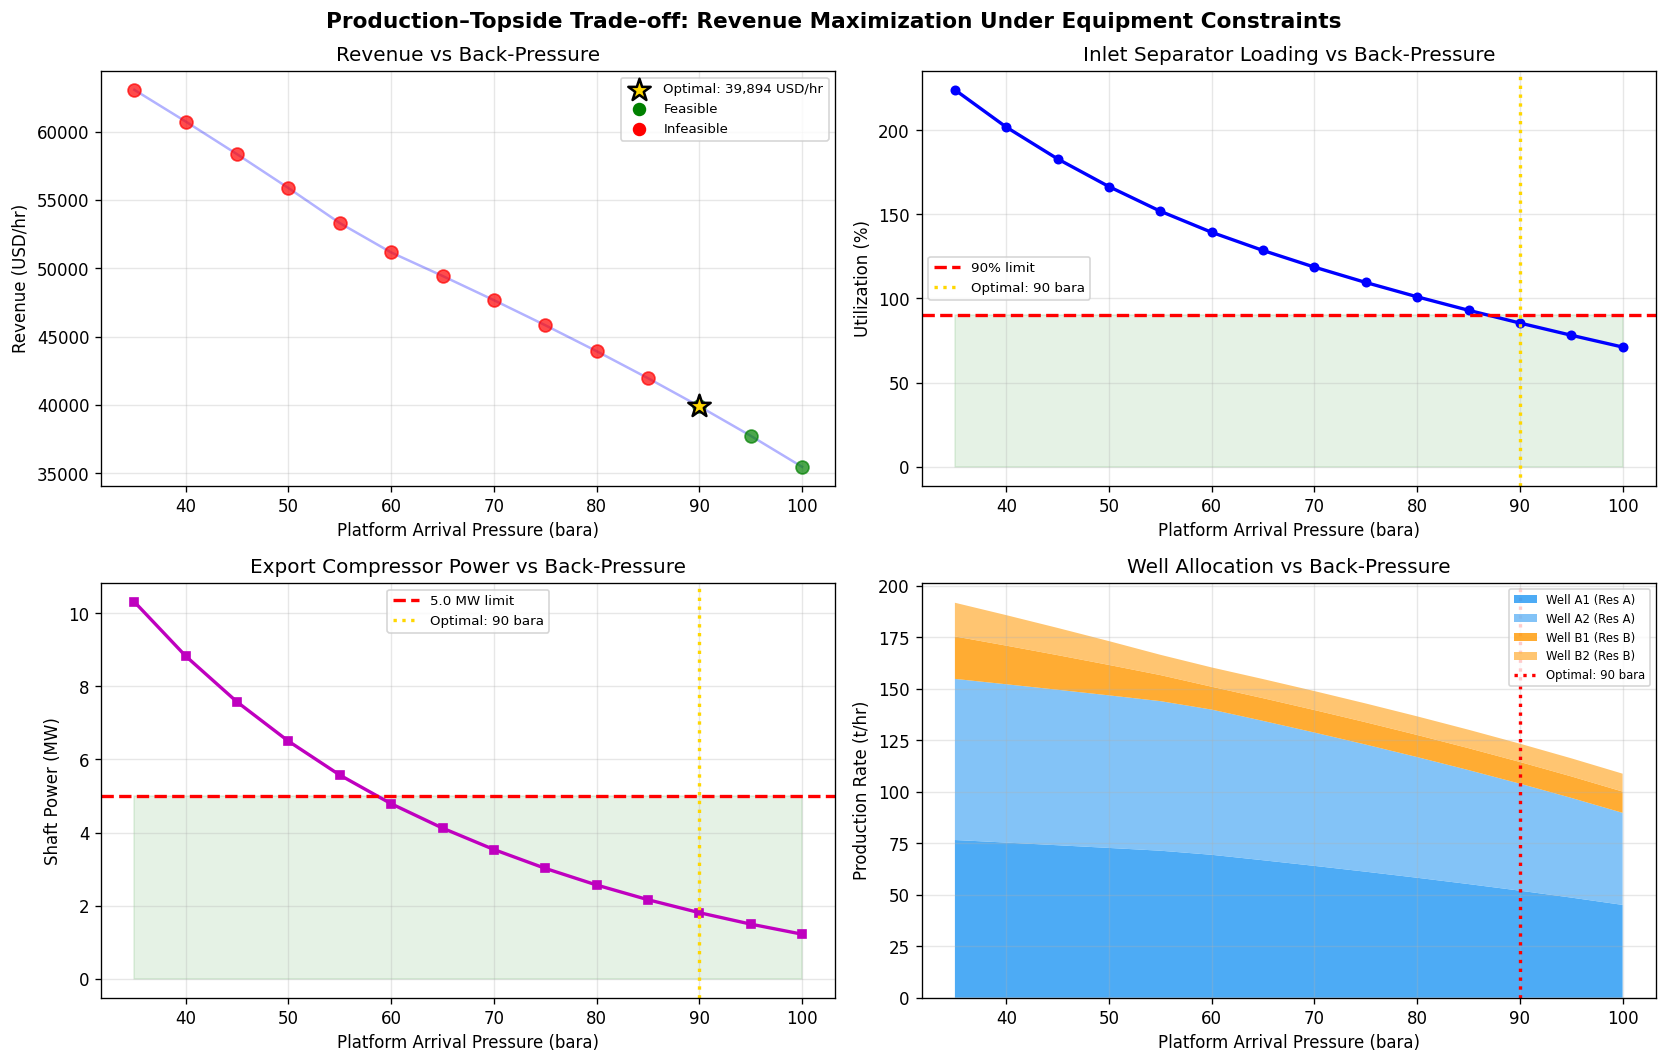


Key Finding: Separator is the binding constraint. Optimal arrival P = 90 bara
Lowering back-pressure below 90 bara would overload the inlet separator.


In [12]:
# =============================================================================
# Cell 6: Visualize coupled production–topside trade-off
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

flows_t = np.array(sweep['total_flow']) / 1000  # Convert to t/hr

# Panel 1: Revenue vs arrival pressure
ax = axes[0, 0]
for i in range(len(sweep['arrival_p'])):
    c = 'green' if sweep['feasible'][i] else 'red'
    ax.scatter(sweep['arrival_p'][i], sweep['revenue'][i], c=c, s=60, zorder=3, alpha=0.7)
ax.plot(sweep['arrival_p'], sweep['revenue'], 'b-', alpha=0.3)
if best_i >= 0:
    ax.scatter(best_p, best_rev, c='gold', s=200, marker='*', zorder=4,
               edgecolors='black', linewidth=1.5, label=f'Optimal: {best_rev:,.0f} USD/hr')
ax.scatter([], [], c='green', s=50, label='Feasible')
ax.scatter([], [], c='red', s=50, label='Infeasible')
ax.set_xlabel('Platform Arrival Pressure (bara)')
ax.set_ylabel('Revenue (USD/hr)')
ax.set_title('Revenue vs Back-Pressure')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Separator utilization vs arrival P
ax = axes[0, 1]
ax.plot(sweep['arrival_p'], sweep['sep_util'], 'b-o', markersize=5, linewidth=2)
ax.axhline(y=MAX_SEP_UTILIZATION*100, color='r', linestyle='--', linewidth=2,
           label=f'{MAX_SEP_UTILIZATION*100:.0f}% limit')
ax.fill_between(sweep['arrival_p'], 0, MAX_SEP_UTILIZATION*100, alpha=0.1, color='green')
if best_i >= 0:
    ax.axvline(x=best_p, color='gold', linestyle=':', linewidth=2, label=f'Optimal: {best_p:.0f} bara')
ax.set_xlabel('Platform Arrival Pressure (bara)')
ax.set_ylabel('Utilization (%)')
ax.set_title('Inlet Separator Loading vs Back-Pressure')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Compressor power vs arrival P
ax = axes[1, 0]
ax.plot(sweep['arrival_p'], sweep['comp_power'], 'm-s', markersize=5, linewidth=2)
ax.axhline(y=MAX_COMPRESSOR_POWER_MW, color='r', linestyle='--', linewidth=2,
           label=f'{MAX_COMPRESSOR_POWER_MW} MW limit')
ax.fill_between(sweep['arrival_p'], 0, MAX_COMPRESSOR_POWER_MW, alpha=0.1, color='green')
if best_i >= 0:
    ax.axvline(x=best_p, color='gold', linestyle=':', linewidth=2, label=f'Optimal: {best_p:.0f} bara')
ax.set_xlabel('Platform Arrival Pressure (bara)')
ax.set_ylabel('Shaft Power (MW)')
ax.set_title('Export Compressor Power vs Back-Pressure')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Production rate + well allocation vs arrival P
ax = axes[1, 1]
ax.stackplot(sweep['arrival_p'],
    [np.array(sweep['rate_A1'])/1000, np.array(sweep['rate_A2'])/1000,
     np.array(sweep['rate_B1'])/1000, np.array(sweep['rate_B2'])/1000],
    labels=['Well A1 (Res A)', 'Well A2 (Res A)', 'Well B1 (Res B)', 'Well B2 (Res B)'],
    colors=['#2196F3', '#64B5F6', '#FF9800', '#FFB74D'], alpha=0.8)
if best_i >= 0:
    ax.axvline(x=best_p, color='red', linestyle=':', linewidth=2, label=f'Optimal: {best_p:.0f} bara')
ax.set_xlabel('Platform Arrival Pressure (bara)')
ax.set_ylabel('Production Rate (t/hr)')
ax.set_title('Well Allocation vs Back-Pressure')
ax.legend(loc='upper right', fontsize=7)
ax.grid(True, alpha=0.3)

fig.suptitle('Production–Topside Trade-off: Revenue Maximization Under Equipment Constraints',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nKey Finding: Separator is the binding constraint. Optimal arrival P = {best_p:.0f} bara")
print(f"Lowering back-pressure below {best_p:.0f} bara would overload the inlet separator.")

## Part 4: Capacity Utilization Dashboard

After optimization, show a comprehensive view of how each topside equipment
is loaded relative to its design capacity.

C:\Users\ESOL\AppData\Local\Temp\ipykernel_34672\215668291.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


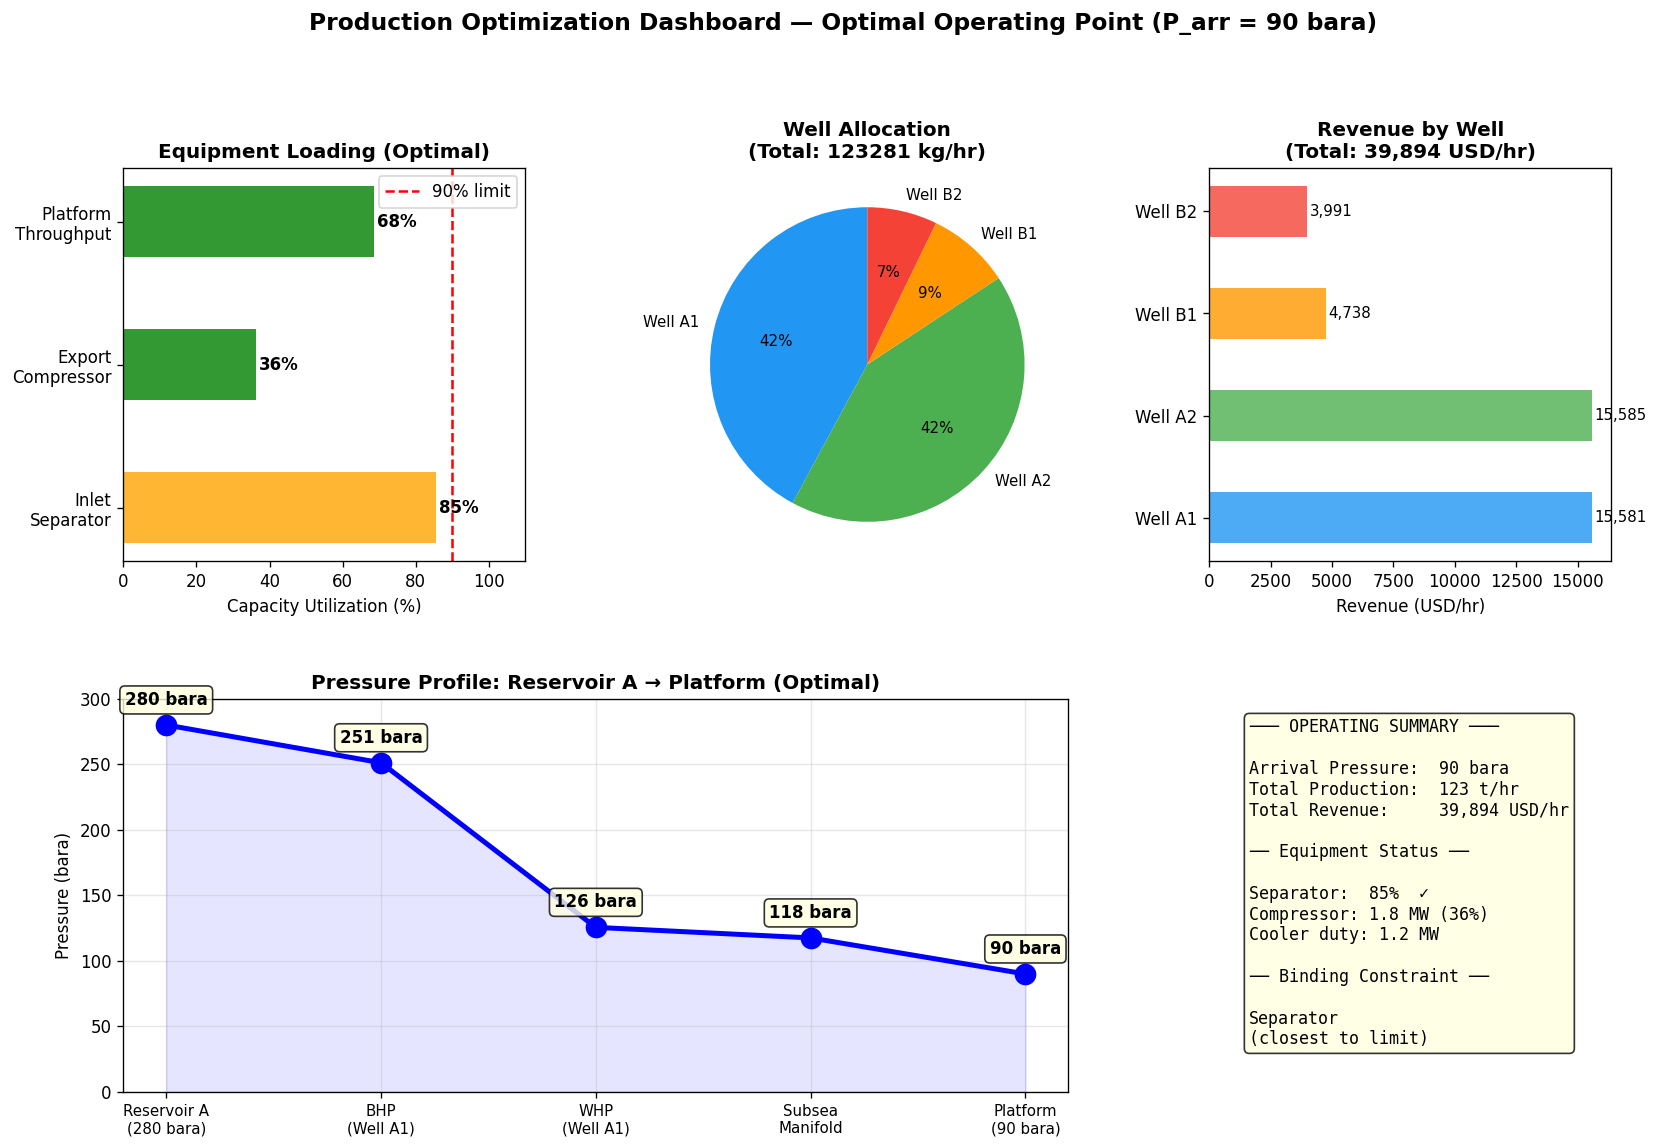


Dashboard shows optimal operating point with P_arrival = 90 bara
Separator is at 85% — the binding topside constraint


In [14]:
# =============================================================================
# Cell 7: Capacity utilization dashboard at optimal operating point
# =============================================================================

# Set main network to optimal arrival pressure from the sweep
net.addFixedPressureSinkNode("platform", float(best_p))
# Restore baseline choke openings (the sweep didn't modify net's chokes)
for chk_name, base_opening in baseline_openings.items():
    net.getPipe(chk_name).setChokeOpening(float(base_opening))
net.run()

# Run topside at optimal point
net_outlet_opt = net.getOutletStream("platform")
topside_opt, sep_opt, comp_opt, cool_opt = build_topside(net_outlet_opt)
topside_opt.run()

# Collect metrics at optimal point
opt_flow = abs(float(net.getTotalSinkFlow())) * 3600
opt_sep_util = float(sep_opt.getCapacityUtilization()) * 100
opt_comp_power = float(comp_opt.getPower("MW"))
opt_comp_util = (opt_comp_power / MAX_COMPRESSOR_POWER_MW) * 100
opt_flow_util = (opt_flow / MAX_TOTAL_FLOW_KGHR) * 100

# Revenue at optimal point
rev_A1 = abs(float(net.getPipeFlowRate("ipr_A1"))) * well_prices['ipr_A1']
rev_A2 = abs(float(net.getPipeFlowRate("ipr_A2"))) * well_prices['ipr_A2']
rev_B1 = abs(float(net.getPipeFlowRate("ipr_B1"))) * well_prices['ipr_B1']
rev_B2 = abs(float(net.getPipeFlowRate("ipr_B2"))) * well_prices['ipr_B2']
opt_revenue = rev_A1 + rev_A2 + rev_B1 + rev_B2

# Dashboard figure
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

# --- Panel 1: Equipment utilization ---
ax1 = fig.add_subplot(gs[0, 0])
equip_names = ['Inlet\nSeparator', 'Export\nCompressor', 'Platform\nThroughput']
equip_utils = [opt_sep_util, opt_comp_util, opt_flow_util]
bar_colors = ['green' if u < 85 else 'orange' if u < 95 else 'red' for u in equip_utils]
bars = ax1.barh(equip_names, equip_utils, color=bar_colors, height=0.5, alpha=0.8)
ax1.axvline(x=90, color='r', linestyle='--', linewidth=1.5, label='90% limit')
ax1.set_xlim(0, 110)
ax1.set_xlabel('Capacity Utilization (%)')
ax1.set_title('Equipment Loading (Optimal)', fontweight='bold')
for bar, val in zip(bars, equip_utils):
    ax1.text(min(val + 1, 100), bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
             va='center', fontweight='bold', fontsize=10)
ax1.legend()

# --- Panel 2: Well allocation pie ---
ax2 = fig.add_subplot(gs[0, 1])
wn = ['Well A1', 'Well A2', 'Well B1', 'Well B2']
wr = [abs(float(net.getPipeFlowRate("ipr_A1"))),
      abs(float(net.getPipeFlowRate("ipr_A2"))),
      abs(float(net.getPipeFlowRate("ipr_B1"))),
      abs(float(net.getPipeFlowRate("ipr_B2")))]
colors_pie = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
ax2.pie(wr, labels=wn, autopct='%1.0f%%', colors=colors_pie,
        startangle=90, textprops={'fontsize': 9})
ax2.set_title(f'Well Allocation\n(Total: {sum(wr):.0f} kg/hr)', fontweight='bold')

# --- Panel 3: Revenue breakdown ---
ax3 = fig.add_subplot(gs[0, 2])
rev_per_well = [rev_A1, rev_A2, rev_B1, rev_B2]
ax3.barh(wn, rev_per_well, color=colors_pie, height=0.5, alpha=0.8)
ax3.set_xlabel('Revenue (USD/hr)')
ax3.set_title(f'Revenue by Well\n(Total: {opt_revenue:,.0f} USD/hr)', fontweight='bold')
for i, val in enumerate(rev_per_well):
    ax3.text(val + 100, i, f'{val:,.0f}', va='center', fontsize=9)

# --- Panel 4: Pressure profile ---
ax4 = fig.add_subplot(gs[1, 0:2])
profile_nodes = ['resA', 'bhp_A1', 'wh_A1', 'manifold', 'platform']
profile_labels = ['Reservoir A\n(280 bara)', 'BHP\n(Well A1)', 'WHP\n(Well A1)',
                  'Subsea\nManifold', f'Platform\n({best_p:.0f} bara)']
profile_pressures = [float(net.getNodePressure(n)) for n in profile_nodes]
ax4.plot(range(len(profile_nodes)), profile_pressures, 'b-o', linewidth=3, markersize=12)
ax4.fill_between(range(len(profile_nodes)), profile_pressures, alpha=0.1, color='blue')
ax4.set_xticks(range(len(profile_nodes)))
ax4.set_xticklabels(profile_labels, fontsize=9)
ax4.set_ylabel('Pressure (bara)')
ax4.set_title('Pressure Profile: Reservoir A → Platform (Optimal)', fontweight='bold')
for i, p in enumerate(profile_pressures):
    ax4.annotate(f'{p:.0f} bara', (i, p), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 300)

# --- Panel 5: Key metrics summary ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
metrics_text = (
    f"─── OPERATING SUMMARY ───\n\n"
    f"Arrival Pressure:  {best_p:.0f} bara\n"
    f"Total Production:  {opt_flow/1000:.0f} t/hr\n"
    f"Total Revenue:     {opt_revenue:,.0f} USD/hr\n\n"
    f"── Equipment Status ──\n\n"
    f"Separator:  {opt_sep_util:.0f}%  {'✓' if opt_sep_util < 90 else '⚠'}\n"
    f"Compressor: {opt_comp_power:.1f} MW ({opt_comp_util:.0f}%)\n"
    f"Cooler duty: {abs(float(cool_opt.getDuty()))/1e6:.1f} MW\n\n"
    f"── Binding Constraint ──\n\n"
    f"{'Separator' if opt_sep_util > opt_comp_util else 'Compressor'}\n"
    f"(closest to limit)"
)
ax5.text(0.1, 0.95, metrics_text, transform=ax5.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle(f'Production Optimization Dashboard — Optimal Operating Point (P_arr = {best_p:.0f} bara)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nDashboard shows optimal operating point with P_arrival = {best_p:.0f} bara")
print(f"Separator is at {opt_sep_util:.0f}% — the binding topside constraint")

## Part 5: Late-Life Production Decline Scenario

Simulate 10 years of reservoir decline and show how topside utilization
drops over time — this highlights the opportunity for **late-life optimization**
(infill wells, re-routing, choke adjustments, gas import, etc.).

In [15]:
# =============================================================================
# Cell 8: Production decline + topside utilization over time
# =============================================================================

# Simulate declining reservoir pressures for both reservoirs
n_years = 11
pres_A_start, pres_A_end = 280.0, 130.0  # bara
pres_B_start, pres_B_end = 220.0, 100.0

years = np.linspace(0, 10, n_years)
pres_A_profile = np.linspace(pres_A_start, pres_A_end, n_years)
pres_B_profile = np.linspace(pres_B_start, pres_B_end, n_years)

# Track production and topside performance at each timestep
results = {'year': [], 'rate_kghr': [], 'sep_util': [], 'comp_power': [],
           'arrival_p': [], 'rate_A1': [], 'rate_A2': [], 'rate_B1': [], 'rate_B2': []}

for i, year in enumerate(years):
    # Create fresh network for each timestep (avoid state accumulation)
    net_t = LoopedPipeNetwork("Year" + str(int(year)))
    net_t.setFluidTemplate(gas)
    net_t.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
    net_t.setMaxIterations(200)
    net_t.setTolerance(float(100.0))

    pA = float(pres_A_profile[i])
    pB = float(pres_B_profile[i])

    net_t.addSourceNode("resA", pA, float(0.0))
    net_t.addJunctionNode("bhp_A1")
    net_t.addJunctionNode("bhp_A2")
    net_t.addJunctionNode("wh_A1")
    net_t.addJunctionNode("wh_A2")
    net_t.addWellIPR("resA", "bhp_A1", "ipr_A1", float(5e-6), False)
    net_t.addWellIPR("resA", "bhp_A2", "ipr_A2", float(4.5e-6), False)
    net_t.addChoke("bhp_A1", "wh_A1", "choke_A1", float(40.0), float(80.0))
    net_t.addChoke("bhp_A2", "wh_A2", "choke_A2", float(40.0), float(75.0))

    net_t.addSourceNode("resB", pB, float(0.0))
    net_t.addJunctionNode("bhp_B1")
    net_t.addJunctionNode("bhp_B2")
    net_t.addJunctionNode("wh_B1")
    net_t.addJunctionNode("wh_B2")
    net_t.addWellIPR("resB", "bhp_B1", "ipr_B1", float(4e-6), False)
    net_t.addWellIPR("resB", "bhp_B2", "ipr_B2", float(3e-6), False)
    net_t.addChoke("bhp_B1", "wh_B1", "choke_B1", float(35.0), float(75.0))
    net_t.addChoke("bhp_B2", "wh_B2", "choke_B2", float(35.0), float(65.0))

    net_t.addJunctionNode("manifold")
    net_t.addPipe("wh_A1", "manifold", "fl_A1", float(5000.0), float(0.20), float(0.00005))
    net_t.addPipe("wh_A2", "manifold", "fl_A2", float(4000.0), float(0.20), float(0.00005))
    net_t.addPipe("wh_B1", "manifold", "fl_B1", float(6000.0), float(0.20), float(0.00005))
    net_t.addPipe("wh_B2", "manifold", "fl_B2", float(7000.0), float(0.20), float(0.00005))
    net_t.addFixedPressureSinkNode("platform", float(65.0))
    net_t.addPipe("manifold", "platform", "export_fl", float(25000.0), float(0.30), float(0.00005))

    try:
        net_t.run()
        total_flow_t = abs(float(net_t.getTotalSinkFlow())) * 3600
        arrival_p_t = float(net_t.getNodePressure("platform"))

        # Run topside
        outlet_t = net_t.getOutletStream("platform")
        top_t, sep_t, comp_t, cool_t = build_topside(outlet_t)
        top_t.run()

        results['year'].append(float(year))
        results['rate_kghr'].append(total_flow_t)
        results['sep_util'].append(float(sep_t.getCapacityUtilization()) * 100)
        results['comp_power'].append(float(comp_t.getPower("MW")))
        results['arrival_p'].append(arrival_p_t)

        # Per-well rates
        results['rate_A1'].append(abs(float(net_t.getPipeFlowRate("ipr_A1"))))
        results['rate_A2'].append(abs(float(net_t.getPipeFlowRate("ipr_A2"))))
        results['rate_B1'].append(abs(float(net_t.getPipeFlowRate("ipr_B1"))))
        results['rate_B2'].append(abs(float(net_t.getPipeFlowRate("ipr_B2"))))
    except Exception as e:
        print(f"Year {year:.0f}: Solver failed — {e}")

print(f"Simulated {len(results['year'])} timesteps over 10 years")
print(f"Peak rate: {max(results['rate_kghr']):.0f} kg/hr (Year {results['year'][results['rate_kghr'].index(max(results['rate_kghr']))]:.0f})")
print(f"End rate:  {results['rate_kghr'][-1]:.0f} kg/hr (Year 10)")
print(f"Decline:   {(1 - results['rate_kghr'][-1]/results['rate_kghr'][0])*100:.0f}%")

Simulated 11 timesteps over 10 years
Peak rate: 155793 kg/hr (Year 0)
End rate:  34336 kg/hr (Year 10)
Decline:   78%


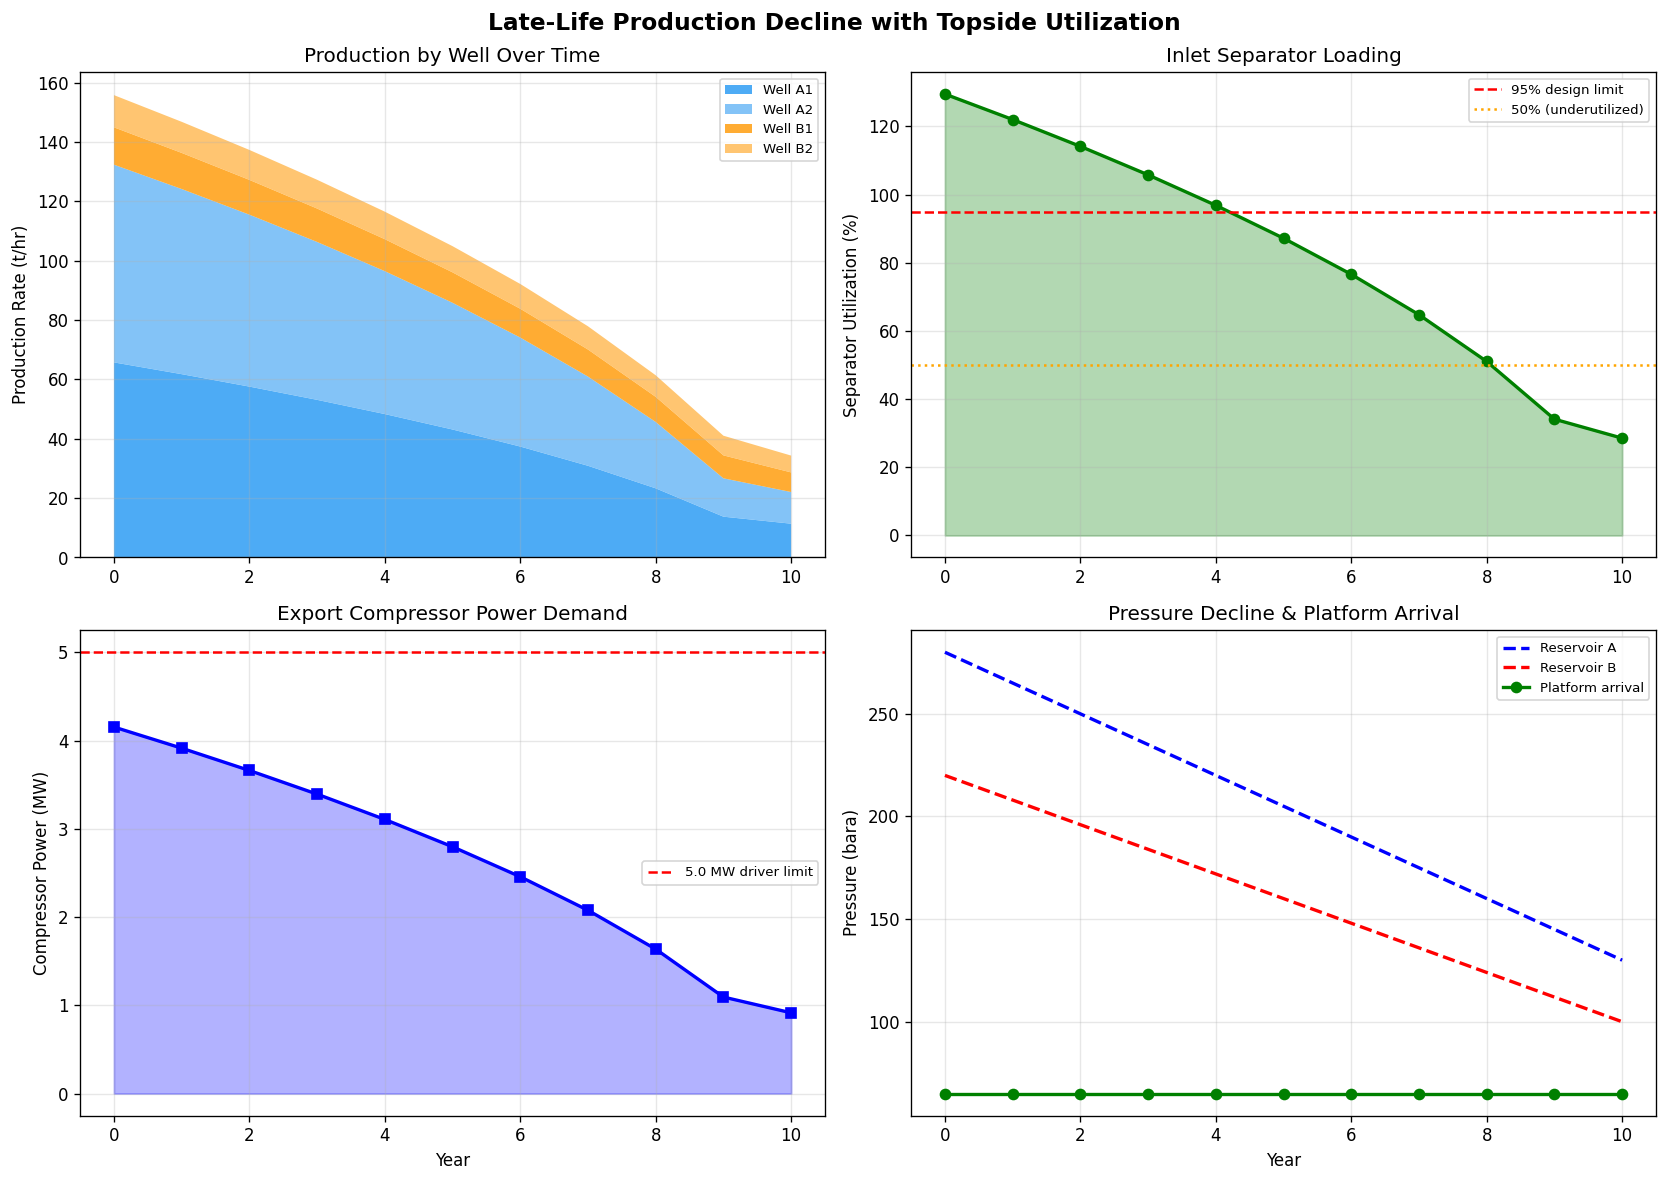


Separator utilization drops from 129% to 29%
Compressor power drops from 4.2 MW to 0.9 MW
At Year 10, separator is only 29% utilized — opportunity for infill drilling


In [16]:
# =============================================================================
# Cell 9: Production decline + topside utilization visualization
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Production rates by well
ax = axes[0, 0]
ax.stackplot(results['year'],
             [np.array(results['rate_A1'])/1000, np.array(results['rate_A2'])/1000,
              np.array(results['rate_B1'])/1000, np.array(results['rate_B2'])/1000],
             labels=['Well A1', 'Well A2', 'Well B1', 'Well B2'],
             colors=['#2196F3', '#64B5F6', '#FF9800', '#FFB74D'], alpha=0.8)
ax.set_ylabel('Production Rate (t/hr)')
ax.set_title('Production by Well Over Time')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Separator utilization
ax = axes[0, 1]
ax.fill_between(results['year'], results['sep_util'], alpha=0.3, color='green')
ax.plot(results['year'], results['sep_util'], 'g-o', linewidth=2)
ax.axhline(y=95, color='r', linestyle='--', label='95% design limit')
ax.axhline(y=50, color='orange', linestyle=':', label='50% (underutilized)')
ax.set_ylabel('Separator Utilization (%)')
ax.set_title('Inlet Separator Loading')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Compressor power
ax = axes[1, 0]
ax.fill_between(results['year'], results['comp_power'], alpha=0.3, color='blue')
ax.plot(results['year'], results['comp_power'], 'b-s', linewidth=2)
ax.axhline(y=MAX_COMPRESSOR_POWER_MW, color='r', linestyle='--', label=f'{MAX_COMPRESSOR_POWER_MW} MW driver limit')
ax.set_ylabel('Compressor Power (MW)')
ax.set_xlabel('Year')
ax.set_title('Export Compressor Power Demand')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Reservoir pressure decline + arrival pressure
ax = axes[1, 1]
ax.plot(years, pres_A_profile, 'b--', linewidth=2, label='Reservoir A')
ax.plot(years, pres_B_profile, 'r--', linewidth=2, label='Reservoir B')
ax.plot(results['year'], results['arrival_p'], 'g-o', linewidth=2, label='Platform arrival')
ax.set_ylabel('Pressure (bara)')
ax.set_xlabel('Year')
ax.set_title('Pressure Decline & Platform Arrival')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle('Late-Life Production Decline with Topside Utilization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
min_sep_util = min(results['sep_util'])
print(f"\nSeparator utilization drops from {results['sep_util'][0]:.0f}% to {results['sep_util'][-1]:.0f}%")
print(f"Compressor power drops from {results['comp_power'][0]:.1f} MW to {results['comp_power'][-1]:.1f} MW")
print(f"At Year 10, separator is only {results['sep_util'][-1]:.0f}% utilized — opportunity for infill drilling")

## Part 6: Topside Debottlenecking — Separator Size Sensitivity

What if we **upgrade the separator**? Sweep separator diameter to find how
topside capacity unlocks more production and revenue. This is a typical
brownfield debottlenecking study.

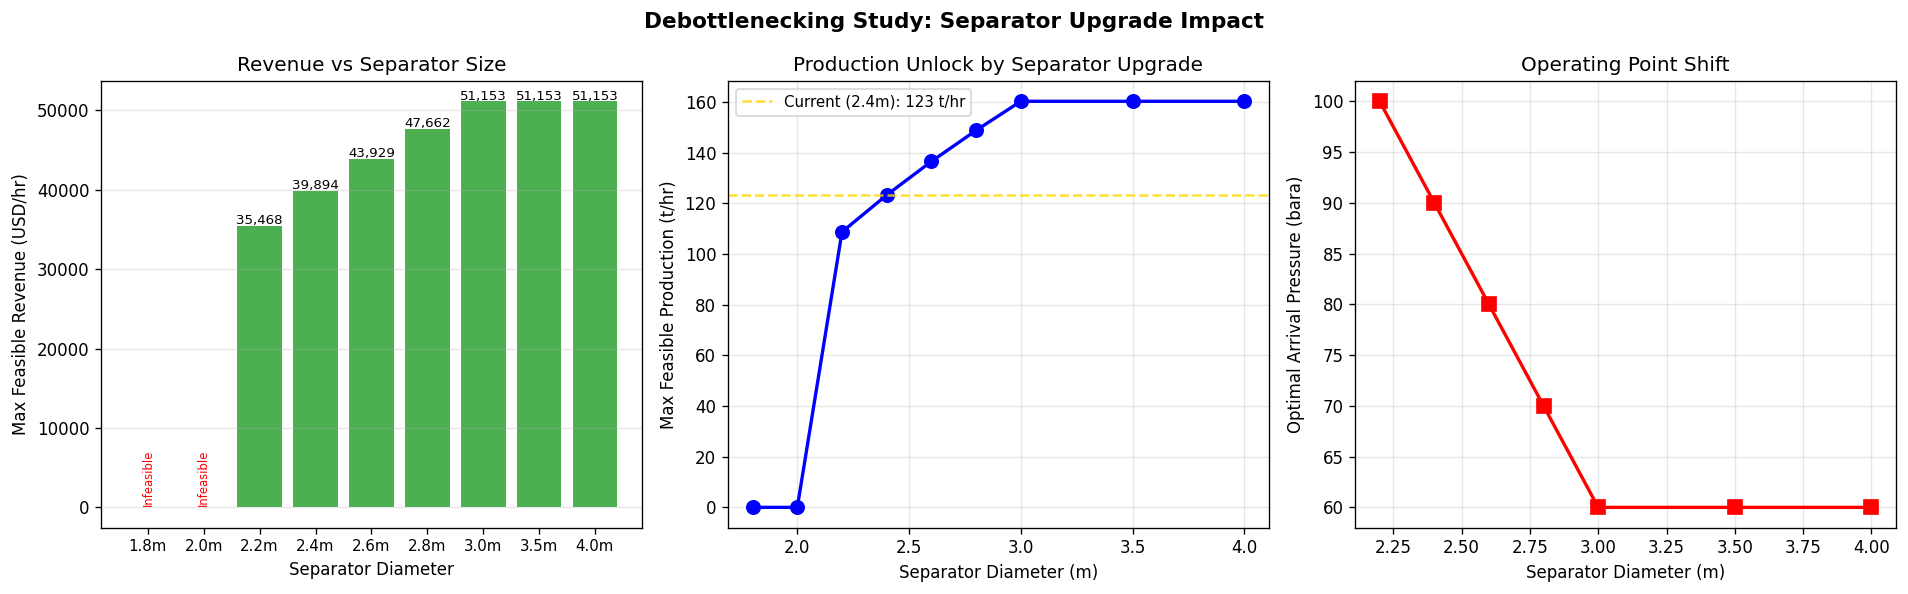


  Diameter  Optimal P   Production      Revenue   Sep Util
------------------------------------------------------------
     1.8 m                                          Infeasible
     2.0 m                                          Infeasible
     2.2 m       100 bara     108,722 kg/hr      35,468 USD/hr       85%
     2.4 m        90 bara     123,281 kg/hr      39,894 USD/hr       85%
     2.6 m        80 bara     136,547 kg/hr      43,929 USD/hr       86%
     2.8 m        70 bara     148,814 kg/hr      47,662 USD/hr       87%
     3.0 m        60 bara     160,280 kg/hr      51,153 USD/hr       89%
     3.5 m        60 bara     160,280 kg/hr      51,153 USD/hr       66%
     4.0 m        60 bara     160,280 kg/hr      51,153 USD/hr       50%

→ Upgrading separator from 2.4m to 3.0m → 28% revenue uplift
  (39,894 → 51,153 USD/hr = +98.6 MUSD/yr)


In [17]:
# =============================================================================
# Cell 10: Separator size sensitivity — debottlenecking study
# =============================================================================

sep_diameters = [1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.5, 4.0]  # metres

debot = {'diameter': [], 'optimal_p': [], 'max_flow': [], 'max_revenue': [],
         'sep_util': [], 'comp_power': []}

for dia in sep_diameters:
    best_rev_d = -1.0
    best_p_d = 0.0
    best_flow_d = 0.0
    best_su_d = 0.0
    best_pw_d = 0.0

    for arr_p in np.arange(40.0, 105.0, 5.0):
        # Build 4-well network for each point
        net_d = LoopedPipeNetwork("Debot")
        net_d.setFluidTemplate(gas)
        net_d.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
        net_d.setMaxIterations(200)
        net_d.setTolerance(float(100.0))

        net_d.addSourceNode("resA", float(280.0), float(0.0))
        net_d.addJunctionNode("bhp_A1"); net_d.addJunctionNode("bhp_A2")
        net_d.addJunctionNode("wh_A1");  net_d.addJunctionNode("wh_A2")
        net_d.addWellIPR("resA", "bhp_A1", "ipr_A1", float(5e-6), False)
        net_d.addWellIPR("resA", "bhp_A2", "ipr_A2", float(4.5e-6), False)
        net_d.addChoke("bhp_A1", "wh_A1", "choke_A1", float(40.0), float(baseline_openings['choke_A1']))
        net_d.addChoke("bhp_A2", "wh_A2", "choke_A2", float(40.0), float(baseline_openings['choke_A2']))

        net_d.addSourceNode("resB", float(220.0), float(0.0))
        net_d.addJunctionNode("bhp_B1"); net_d.addJunctionNode("bhp_B2")
        net_d.addJunctionNode("wh_B1");  net_d.addJunctionNode("wh_B2")
        net_d.addWellIPR("resB", "bhp_B1", "ipr_B1", float(4e-6), False)
        net_d.addWellIPR("resB", "bhp_B2", "ipr_B2", float(3e-6), False)
        net_d.addChoke("bhp_B1", "wh_B1", "choke_B1", float(35.0), float(baseline_openings['choke_B1']))
        net_d.addChoke("bhp_B2", "wh_B2", "choke_B2", float(35.0), float(baseline_openings['choke_B2']))

        net_d.addJunctionNode("manifold")
        net_d.addPipe("wh_A1", "manifold", "fl_A1", float(5000.0), float(0.20), float(0.00005))
        net_d.addPipe("wh_A2", "manifold", "fl_A2", float(4000.0), float(0.20), float(0.00005))
        net_d.addPipe("wh_B1", "manifold", "fl_B1", float(6000.0), float(0.20), float(0.00005))
        net_d.addPipe("wh_B2", "manifold", "fl_B2", float(7000.0), float(0.20), float(0.00005))
        net_d.addFixedPressureSinkNode("platform", float(arr_p))
        net_d.addPipe("manifold", "platform", "export_fl", float(25000.0), float(0.30), float(0.00005))

        try:
            net_d.run()
            flow_d = abs(float(net_d.getTotalSinkFlow())) * 3600
            outlet_d = net_d.getOutletStream("platform")

            # Build topside with custom separator diameter
            feed_d = Stream("Feed", outlet_d.getFluid().clone())
            feed_d.setFlowRate(outlet_d.getFlowRate("kg/hr"), "kg/hr")
            feed_d.setTemperature(outlet_d.getTemperature("C"), "C")
            feed_d.setPressure(outlet_d.getPressure("bara"), "bara")

            sep_d = Separator("Sep", feed_d)
            sep_d.setInternalDiameter(float(dia))
            sep_d.setSeparatorLength(float(10.0))
            sep_d.setOrientation("horizontal")
            sep_d.setDesignGasLoadFactor(float(0.06))

            comp_d = Compressor("Comp", sep_d.getGasOutStream())
            comp_d.setOutletPressure(EXPORT_PRESSURE)
            comp_d.setPolytropicEfficiency(0.78)

            top_d = ProcessSystem()
            top_d.add(feed_d)
            top_d.add(sep_d)
            top_d.add(comp_d)
            top_d.run()

            su_d = float(sep_d.getCapacityUtilization())
            pw_d = float(comp_d.getPower("MW"))

            # Revenue from well rates
            r_d = sum(abs(float(net_d.getPipeFlowRate(ipr))) * well_prices[ipr]
                       for _, ipr, _, _, _ in wells)

            if su_d <= MAX_SEP_UTILIZATION and pw_d <= MAX_COMPRESSOR_POWER_MW and r_d > best_rev_d:
                best_rev_d = r_d
                best_p_d = float(arr_p)
                best_flow_d = flow_d
                best_su_d = su_d * 100
                best_pw_d = pw_d
        except Exception:
            pass

    debot['diameter'].append(dia)
    debot['optimal_p'].append(best_p_d)
    debot['max_flow'].append(best_flow_d)
    debot['max_revenue'].append(best_rev_d)
    debot['sep_util'].append(best_su_d)
    debot['comp_power'].append(best_pw_d)

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Revenue uplift vs separator diameter
ax = axes[0]
ax.bar(range(len(debot['diameter'])), debot['max_revenue'],
       color=['#4CAF50' if r > 0 else '#ccc' for r in debot['max_revenue']])
ax.set_xticks(range(len(debot['diameter'])))
ax.set_xticklabels([f'{d:.1f}m' for d in debot['diameter']], fontsize=9)
ax.set_xlabel('Separator Diameter')
ax.set_ylabel('Max Feasible Revenue (USD/hr)')
ax.set_title('Revenue vs Separator Size')
ax.grid(True, alpha=0.3, axis='y')
# Annotate bars
for i, r in enumerate(debot['max_revenue']):
    if r > 0:
        ax.text(i, r + 200, f'{r:,.0f}', ha='center', fontsize=8)
    else:
        ax.text(i, 500, 'Infeasible', ha='center', fontsize=7, color='red', rotation=90)

# Production unlock
ax = axes[1]
flows_valid = [f/1000 if f > 0 else 0 for f in debot['max_flow']]
ax.plot(debot['diameter'], flows_valid, 'b-o', linewidth=2, markersize=8)
ax.axhline(y=best_flow/1000, color='gold', linestyle='--', alpha=0.8,
           label=f'Current (2.4m): {best_flow/1000:.0f} t/hr')
ax.set_xlabel('Separator Diameter (m)')
ax.set_ylabel('Max Feasible Production (t/hr)')
ax.set_title('Production Unlock by Separator Upgrade')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Optimal arrival pressure
ax = axes[2]
valid_p = [p if p > 0 else None for p in debot['optimal_p']]
ax.plot(debot['diameter'], valid_p, 'r-s', linewidth=2, markersize=8)
ax.set_xlabel('Separator Diameter (m)')
ax.set_ylabel('Optimal Arrival Pressure (bara)')
ax.set_title('Operating Point Shift')
ax.grid(True, alpha=0.3)

plt.suptitle('Debottlenecking Study: Separator Upgrade Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Diameter':>10s} {'Optimal P':>10s} {'Production':>12s} {'Revenue':>12s} {'Sep Util':>10s}")
print("-" * 60)
for i in range(len(debot['diameter'])):
    if debot['max_revenue'][i] > 0:
        print(f"{debot['diameter'][i]:>8.1f} m  {debot['optimal_p'][i]:>8.0f} bara"
              f"  {debot['max_flow'][i]:>10,.0f} kg/hr  {debot['max_revenue'][i]:>10,.0f} USD/hr"
              f"  {debot['sep_util'][i]:>7.0f}%")
    else:
        print(f"{debot['diameter'][i]:>8.1f} m  {'Infeasible':>50s}")

# Revenue uplift from debottlenecking
base_rev = debot['max_revenue'][debot['diameter'].index(2.4)]
max_rev = max(debot['max_revenue'])
max_dia = debot['diameter'][debot['max_revenue'].index(max_rev)]
if base_rev > 0 and max_rev > base_rev:
    uplift_pct = (max_rev / base_rev - 1) * 100
    print(f"\n→ Upgrading separator from 2.4m to {max_dia:.1f}m → {uplift_pct:.0f}% revenue uplift")
    print(f"  ({base_rev:,.0f} → {max_rev:,.0f} USD/hr = +{(max_rev-base_rev)*8760/1e6:.1f} MUSD/yr)")

## Part 7: Improvement Proposals

Based on this analysis, here are the **gaps and improvements** needed to make
NeqSim truly state-of-the-art for integrated production–topside optimization.

In [18]:
# =============================================================================
# Cell 11: Gap analysis and improvement proposals
# =============================================================================

print("="*80)
print("  IMPROVEMENT PROPOSALS: Integrated Production–Topside Optimization")
print("="*80)

proposals = [
    {
        "id": "P1",
        "title": "Built-in Network–Topside Coupling Loop",
        "status": "GAP — Currently requires manual Python iteration",
        "description":
            "Add setTopsideModel(ProcessSystem) to LoopedPipeNetwork.\n"
            "When run() completes, automatically feed outlet streams to the topside\n"
            "ProcessSystem, run it, and read back the inlet separator pressure as\n"
            "the new sink pressure. Iterate until pressure converges (< 0.1 bar delta).",
        "priority": "HIGH",
        "effort": "Medium (2-3 days)"
    },
    {
        "id": "P2",
        "title": "Topside Constraint Feedback in Optimizer",
        "status": "GAP — optimizeProduction() ignores topside equipment capacity",
        "description":
            "Extend optimizeProduction() to accept a callback or constraint function\n"
            "that evaluates topside capacity after each network solve. Penalize the\n"
            "objective when separator utilization > limit or compressor exceeds power.\n"
            "This would replace the manual Python loop with a single Java call:",
        "priority": "HIGH",
        "effort": "Medium (2 days) — add CapacityConstraint interface"
    },
    {
        "id": "P3",
        "title": "Dynamic Sink Pressure Update API",
        "status": "PARTIAL — Can call addFixedPressureSinkNode() to overwrite",
        "description":
            "Add setNodePressure(String name, double bara) to update an existing\n"
            "node's pressure without recreating it. This simplifies the coupling loop.\n"
            "Currently requires getNode(name).setPressure(P*1e5) which exposes internals.",
        "priority": "MEDIUM",
        "effort": "Low (0.5 days)"
    },
    {
        "id": "P4",
        "title": "Compressor Power Budget Constraint",
        "status": "GAP — No shared power budget across network + topside compressors",
        "description":
            "Add setMaxTotalCompressorPower(double MW) to the coupled model. When\n"
            "network compressors + topside compressors exceed the gas turbine driver\n"
            "budget, flag this as a constraint violation. Essential for platforms\n"
            "where subsea boosting and topside compression share power.",
        "priority": "MEDIUM",
        "effort": "Medium (2 days)"
    },
    {
        "id": "P5",
        "title": "Multi-Timestep Decline + Re-optimization",
        "status": "PARTIAL — productionForecast() exists but doesn't re-optimize chokes",
        "description":
            "Extend productionForecast() to run optimizeProduction() at each timestep,\n"
            "or add a productionForecastWithOptimization() method. This models how\n"
            "operators actually manage fields: re-set chokes as reservoirs decline.\n"
            "Also include topside constraint checking at each timestep.",
        "priority": "HIGH",
        "effort": "Medium (2 days)"
    },
    {
        "id": "P6",
        "title": "ProcessModel Integration (Network as a Process Area)",
        "status": "GAP — Network can be in ProcessSystem but not in ProcessModel with iteration",
        "description":
            "Allow LoopedPipeNetwork to be a first-class participant in ProcessModel\n"
            "multi-area iteration. Currently ProcessModel iterates ProcessSystems but\n"
            "the network back-pressure update requires explicit wiring. A NetworkProcessArea\n"
            "adapter could bridge this.",
        "priority": "MEDIUM",
        "effort": "High (3-5 days)"
    },
    {
        "id": "P7",
        "title": "Topside Equipment Auto-Sizing from Network Output",
        "status": "PARTIAL — Separator has autoSize(), but not driven by network",
        "description":
            "After the network solves, automatically call sep.autoSize() on the topside\n"
            "separator based on the production rate. Then check if existing equipment\n"
            "can handle the flow, or if modifications are needed. This enables\n"
            "brownfield capacity assessment.",
        "priority": "LOW",
        "effort": "Low (1 day)"
    },
    {
        "id": "P8",
        "title": "Fuel Gas Extraction from Process Gas",
        "status": "GAP — Fuel gas is simplified heat-rate model, not a real stream",
        "description":
            "Replace the simple kJ/kWh fuel gas model with actual fuel gas extraction.\n"
            "In real platforms, 1-3% of process gas feeds the gas turbine. This should\n"
            "be modeled as a splitter tee + gas turbine in the topside process. The\n"
            "fuel gas consumption affects the remaining export gas quantity.",
        "priority": "MEDIUM",
        "effort": "Medium (2 days)"
    },
]

# Print proposals
for p in proposals:
    icon = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}.get(p['priority'], "⚪")
    print(f"\n{icon} [{p['id']}] {p['title']}")
    print(f"   Status:   {p['status']}")
    print(f"   Priority: {p['priority']} | Effort: {p['effort']}")
    for line in p['description'].split('\n'):
        print(f"   {line}")

print("\n" + "="*80)
print("  WHAT WORKS WELL TODAY")
print("="*80)
strengths = [
    "✓ LoopedPipeNetwork.getOutletStream() provides plug-in stream to ProcessSystem",
    "✓ Separator.getCapacityUtilization() returns real-time gas load vs K-factor limit",
    "✓ Compressor.getPower() gives accurate polytropic shaft power",
    "✓ optimizeProduction() with revenue-weighting + Armijo line search",
    "✓ sensitivityAnalysis() for parametric sweeps (choke, reservoir P, PI, pipe dia)",
    "✓ productionForecast() for time-stepped reservoir decline",
    "✓ generateCoupledVFPTables() for Eclipse/OPM-compatible output",
    "✓ Per-well composition tracking with mass-weighted mixing at junctions",
    "✓ Constraint checking (pressure limits, flow limits, erosional velocity)",
    "✓ Well allocation reporting (rate, revenue, choke opening per well)",
]
for s in strengths:
    print(f"  {s}")

print("\n" + "="*80)
print("  RECOMMENDED IMPLEMENTATION ORDER")
print("="*80)
print("  1. P3 — setNodePressure() API (0.5 days — quick win)")
print("  2. P1 — Built-in coupling loop (2-3 days — highest impact)")
print("  3. P5 — Forecast with re-optimization (2 days — real operations)")
print("  4. P2 — Topside constraint in optimizer (2 days)")
print("  5. P4 — Power budget constraint (2 days)")
print("  6. P8 — Fuel gas extraction (2 days)")
print("  7. P6 — ProcessModel integration (3-5 days)")
print("  8. P7 — Auto-sizing from network (1 day)")

  IMPROVEMENT PROPOSALS: Integrated Production–Topside Optimization

🔴 [P1] Built-in Network–Topside Coupling Loop
   Status:   GAP — Currently requires manual Python iteration
   Priority: HIGH | Effort: Medium (2-3 days)
   Add setTopsideModel(ProcessSystem) to LoopedPipeNetwork.
   When run() completes, automatically feed outlet streams to the topside
   ProcessSystem, run it, and read back the inlet separator pressure as
   the new sink pressure. Iterate until pressure converges (< 0.1 bar delta).

🔴 [P2] Topside Constraint Feedback in Optimizer
   Status:   GAP — optimizeProduction() ignores topside equipment capacity
   Priority: HIGH | Effort: Medium (2 days) — add CapacityConstraint interface
   Extend optimizeProduction() to accept a callback or constraint function
   that evaluates topside capacity after each network solve. Penalize the
   objective when separator utilization > limit or compressor exceeds power.
   This would replace the manual Python loop with a single Java 